In [10]:
import sklearn as skl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing

from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [11]:
train = pd.read_csv("datasets/training_data.csv", encoding='utf-8', encoding_errors='ignore')
test = pd.read_csv("datasets/test_data.csv", encoding='utf-8', encoding_errors='ignore')

In [12]:
print("Dimensão do treino:", train.shape)
print("Dimensão do teste:", test.shape)
print("\nColunas:", train.columns.tolist())

Dimensão do treino: (6812, 14)
Dimensão do teste: (1500, 13)

Colunas: ['city_name', 'record_date', 'AVERAGE_SPEED_DIFF', 'AVERAGE_FREE_FLOW_SPEED', 'AVERAGE_TIME_DIFF', 'AVERAGE_FREE_FLOW_TIME', 'LUMINOSITY', 'AVERAGE_TEMPERATURE', 'AVERAGE_ATMOSP_PRESSURE', 'AVERAGE_HUMIDITY', 'AVERAGE_WIND_SPEED', 'AVERAGE_CLOUDINESS', 'AVERAGE_PRECIPITATION', 'AVERAGE_RAIN']


In [13]:
# ====================================================
# 3️⃣ PRÉ-PROCESSAMENTO
# ====================================================

# Remover colunas vazias se existirem
train.drop(columns=["AVERAGE_PRECIPITATION", "AVERAGE_RAIN"], errors="ignore", inplace=True)
test.drop(columns=["AVERAGE_PRECIPITATION", "AVERAGE_RAIN"], errors="ignore", inplace=True)

In [14]:
# Converter record_date em colunas úteis
for df in [train, test]:
    df["record_date"] = pd.to_datetime(df["record_date"], errors="coerce", dayfirst=True)
    df["hour"] = df["record_date"].dt.hour
    df["dayofweek"] = df["record_date"].dt.dayofweek
    df["month"] = df["record_date"].dt.month
    df.drop(columns=["record_date"], inplace=True)


/var/folders/1j/0ym_j9j544d0fq15xcj3nh0r0000gn/T/ipykernel_47810/3600396514.py:3: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["record_date"] = pd.to_datetime(df["record_date"], errors="coerce", dayfirst=True)
/var/folders/1j/0ym_j9j544d0fq15xcj3nh0r0000gn/T/ipykernel_47810/3600396514.py:3: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["record_date"] = pd.to_datetime(df["record_date"], errors="coerce", dayfirst=True)


In [15]:
# ====================================================
# 4️⃣ SEPARAR FEATURES E TARGET
# ====================================================
y = train["AVERAGE_SPEED_DIFF"].astype(str)   # target (string: None, Low, Medium, etc.)
X = train.drop(columns=["AVERAGE_SPEED_DIFF"])

# One-hot encoding (transformar texto em colunas binárias)
X = pd.get_dummies(X)
X_test = pd.get_dummies(test)

# Garantir que ambos têm as mesmas colunas
X_test = X_test.reindex(columns=X.columns, fill_value=0)


In [16]:
# ====================================================
# 5️⃣ NORMALIZAÇÃO DOS DADOS
# ====================================================
from sklearn.discriminant_analysis import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)


In [17]:
# ====================================================
# 6️⃣ TREINO INICIAL (Random Forest)
# ====================================================
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(rf, X_scaled, y, cv=5, scoring="accuracy")
print("\nValidação cruzada inicial:")
print("Scores individuais:", scores)
print("Accuracy médio:", round(np.mean(scores), 4))



Validação cruzada inicial:
Scores individuais: [0.77989729 0.78943507 0.80690162 0.78267254 0.79221733]
Accuracy médio: 0.7902


In [18]:
# ====================================================
# 7️⃣ TUNING AUTOMÁTICO (RandomizedSearchCV)
# ====================================================
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(200, 500),
    'max_depth': randint(10, 40),
    'min_samples_split': randint(2, 8),
    'min_samples_leaf': randint(1, 4)
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\nA otimizar parâmetros...")
search.fit(X_scaled, y)

print("\nMelhores parâmetros encontrados:")
print(search.best_params_)
print("Melhor accuracy validada:", round(search.best_score_, 4))

best_rf = search.best_estimator_



A otimizar parâmetros...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Melhores parâmetros encontrados:
{'max_depth': 35, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 291}
Melhor accuracy validada: 0.7955



Accuracy final médio: 0.7955


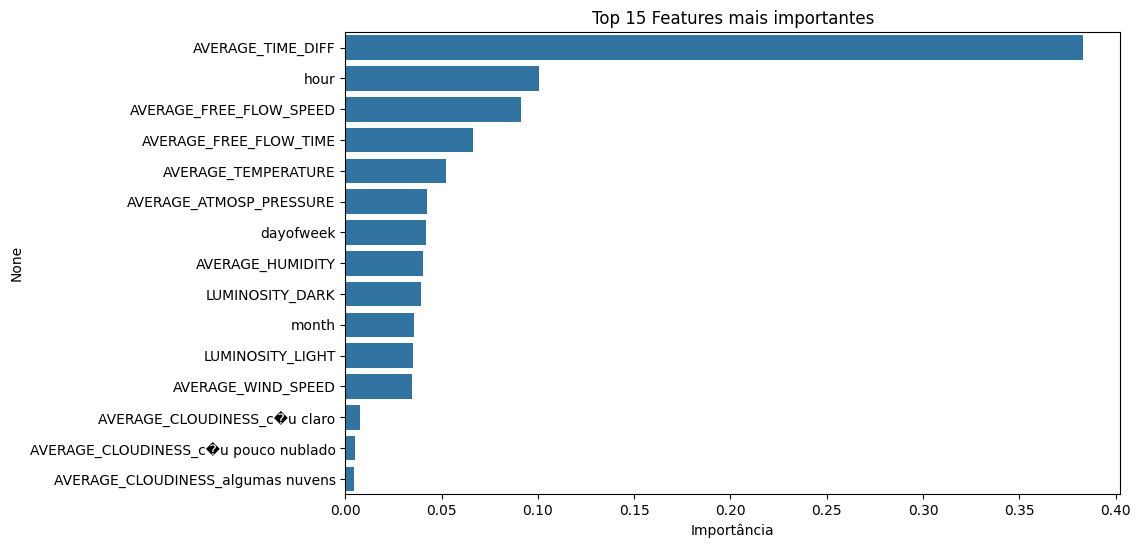


✅ Ficheiro 'submission.csv' criado com sucesso!


In [19]:
# ====================================================
# 8️⃣ TREINAR MODELO FINAL
# ====================================================
best_rf.fit(X_scaled, y)

# Avaliação final com cross-validation
final_scores = cross_val_score(best_rf, X_scaled, y, cv=5, scoring="accuracy")
print("\nAccuracy final médio:", round(np.mean(final_scores), 4))

# ====================================================
# 9️⃣ FEATURE IMPORTANCE (opcional mas bom p/ relatório)
# ====================================================
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances[:15], y=importances.index[:15])
plt.title("Top 15 Features mais importantes")
plt.xlabel("Importância")
plt.show()

# ====================================================
# 🔟 PREVER E GERAR SUBMISSÃO
# ====================================================
preds = best_rf.predict(X_test_scaled)

submission = pd.DataFrame({
    "RowId": range(1, len(preds)+1),
    "Speed_Diff": preds
})

submission.to_csv("submission.csv", index=False)
print("\n✅ Ficheiro 'submission.csv' criado com sucesso!")